# Face Verification with Pretrained iResNet50
## One-shot Attendance System Demo

**Model:** iResNet50 Backbone (pretrained with ArcFace on VGGFace2 subset)
**Input:** 112x112, normalized [-1, 1]
**Preprocessing:** MTCNN detect -> eye-alignment -> expand bbox -> resize 112 -> norm
**Output:** 512-D L2-normalized embedding
**Method:** Cosine similarity + threshold -> Same/Different

### Sections
1. Setup & Import
2. Load Pretrained Model
3. Test with test_one_shot Images (demo MTCNN preprocessing)
4. Evaluate on dataset_final (EER, AUC, ROC, Score Distribution)
5. One-shot Attendance Workflow (enroll -> identify)
6. Find Best Threshold

---
## 1. Setup & Import

In [27]:
import os
import sys
from pathlib import Path

while not os.path.exists('dataset') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)
print(f'Project root: {os.getcwd()}')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'{len(gpus)} GPU(s) ready')
else:
    print('CPU mode')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Project root: c:\Users\Admin\Desktop\Project_DAT301m
1 GPU(s) ready


---
## 2. Load Pretrained Model

Load the iResNet50 backbone trained with ArcFace on dataset_final (432 identities, 112x112 aligned).
The verifier uses MTCNN face detection + eye alignment (matching dataset_final pipeline).

In [28]:
from using_pretrained_model.verifier import FaceVerifier

WEIGHTS_PATH = 'models/face_recognition/iresnet/results/arcface/best_iresnet50_backbone.h5'
THRESHOLD = 0.30
TEST_DIR = 'dataset_final/test'

verifier = FaceVerifier(
    weights_path=WEIGHTS_PATH,
    threshold=THRESHOLD,
    img_size=112,
    dropout_rate=0.4,
)
print('Model ready.')

[FaceVerifier] Loaded weights from: models/face_recognition/iresnet/results/arcface/best_iresnet50_backbone.h5
[FaceVerifier] Threshold: 0.3000
Model ready.


---
## 3. Test with test_one_shot Images

Demonstrate MTCNN-aligned pipeline on raw images.

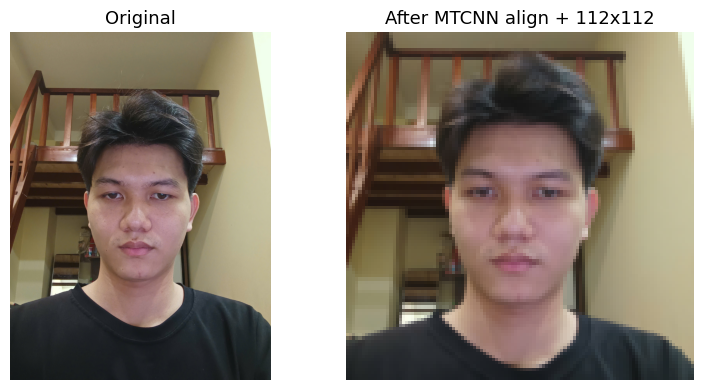

In [29]:
img_a = r'C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\origin.jpg'
img_b = r'C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test5.png'

# Show preprocessing
processed_a = verifier.preprocess(img_a)
original_a = Image.open(img_a).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_a)
axes[0].set_title('Original', fontsize=13)
axes[0].axis('off')
axes[1].imshow((processed_a + 1) / 2)
axes[1].set_title('After MTCNN align + 112x112', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.show()

Image A:  C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\origin.jpg
Image B:  C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test5.png
Cosine Similarity: 0.0717
Threshold:         0.3000
Result:            DIFFERENT PERSON


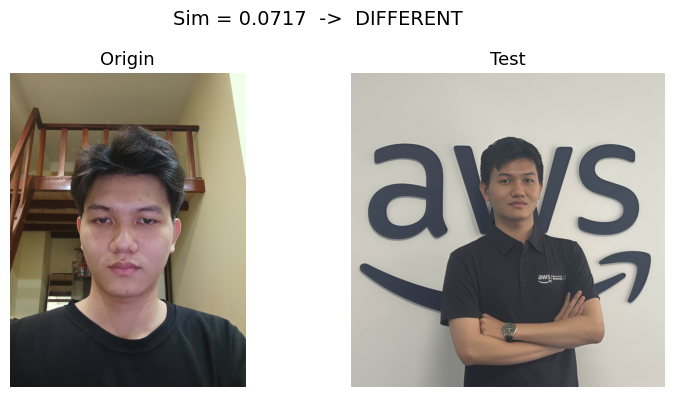

In [30]:
is_same, sim = verifier.verify(img_a, img_b)

print(f'Image A:  {img_a}')
print(f'Image B:  {img_b}')
print(f'Cosine Similarity: {sim:.4f}')
print(f'Threshold:         {verifier.threshold:.4f}')
print(f'Result:            {"SAME PERSON" if is_same else "DIFFERENT PERSON"}')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(img_a).convert('RGB'))
axes[0].set_title('Origin', fontsize=13); axes[0].axis('off')
axes[1].imshow(Image.open(img_b).convert('RGB'))
axes[1].set_title('Test', fontsize=13); axes[1].axis('off')
plt.suptitle(f'Sim = {sim:.4f}  ->  {"SAME" if is_same else "DIFFERENT"}', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Evaluate on dataset_final/test

Systematic verification on 108 unseen identities (39K images).

In [31]:
print('Evaluating on dataset_final/test...')
results = verifier.evaluate_dataset(
    dataset_dir=TEST_DIR,
    num_pairs=5000,
    seed=42,
)

print(f"\n{'='*50}")
print('Verification Results (108 unseen identities)')
print(f"{'='*50}")
print(f"  EER:              {results['eer']*100:.2f}%")
print(f"  EER Threshold:    {results['threshold_eer']:.4f}")
print(f"  AUC:              {results['auc']:.4f}")
print(f"  Accuracy @ EER:   {results['accuracy']*100:.2f}%")
print(f"  Pos similarity:   {results['pos_mean']:.4f} +- {results['pos_std']:.4f}")
print(f"  Neg similarity:   {results['neg_mean']:.4f} +- {results['neg_std']:.4f}")
print(f"  Separation gap:   {results['pos_mean'] - results['neg_mean']:.4f}")
print(f"{'='*50}")

Evaluating on dataset_final/test...
[Eval] Extracting embeddings for 108 identities...
[Eval] Done. Generating 5000 positive + 5000 negative pairs...

Verification Results (108 unseen identities)
  EER:              20.88%
  EER Threshold:    0.0943
  AUC:              0.8702
  Accuracy @ EER:   79.12%
  Pos similarity:   0.2427 +- 0.1744
  Neg similarity:   0.0137 +- 0.1042
  Separation gap:   0.2290


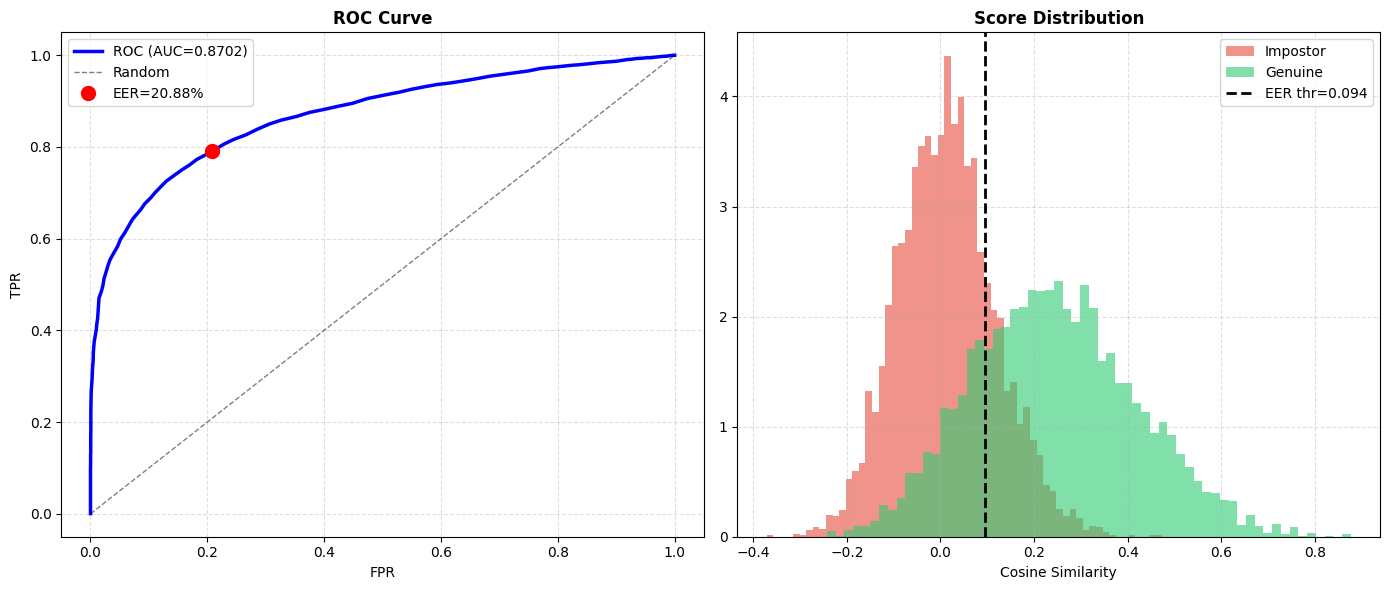

In [32]:
y = np.array(results['y_true'])
s = np.array(results['all_scores'])
pos_s = np.array(results['pos_scores'])
neg_s = np.array(results['neg_scores'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
thresholds = np.linspace(s.min(), s.max(), 200)
fprs, tprs = [], []
n_pos, n_neg = int(np.sum(y)), int(len(y) - np.sum(y))
for t in thresholds:
    pred = (s >= t).astype(int)
    fprs.append(np.sum(pred & (y == 0)) / max(n_neg, 1))
    tprs.append(np.sum(pred & (y == 1)) / max(n_pos, 1))
ax.plot(fprs, tprs, 'b-', lw=2.5, label=f"ROC (AUC={results['auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.plot(results['eer'], 1 - results['eer'], 'ro', ms=10,
        label=f"EER={results['eer']*100:.2f}%")
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# Score Distribution
ax = axes[1]
ax.hist(neg_s, bins=60, alpha=0.6, color='#e74c3c', label='Impostor', density=True)
ax.hist(pos_s, bins=60, alpha=0.6, color='#2ecc71', label='Genuine', density=True)
ax.axvline(results['threshold_eer'], color='k', ls='--', lw=2,
           label=f"EER thr={results['threshold_eer']:.3f}")
ax.set_xlabel('Cosine Similarity')
ax.set_title('Score Distribution', fontweight='bold')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout(); plt.show()

---
## 5. One-shot Attendance Workflow

1. **Enroll**: Register 10 employees (1 reference photo each)
2. **Identify**: Query photo -> find matching identity
3. **Unknown**: Test with person NOT in gallery

In [33]:
test_path = Path(TEST_DIR)
all_ids = sorted([d.name for d in test_path.iterdir() if d.is_dir()])
rng = random.Random(42)
employees = rng.sample(all_ids, min(10, len(all_ids)))

gallery_paths, gallery_names = [], []
for eid in employees:
    imgs = sorted((test_path / eid).glob('*.jpg'))
    if len(imgs) >= 2:
        gallery_paths.append(str(imgs[0]))
        gallery_names.append(eid)

gallery = verifier.enroll(gallery_paths, gallery_names)
print(f'Enrolled {len(gallery)} employees')

Enrolled 10 employees


In [34]:
correct, total = 0, 0
for eid in employees:
    imgs = sorted((test_path / eid).glob('*.jpg'))
    if len(imgs) < 2:
        continue
    query = str(imgs[1])
    best_id, best_sim, matched = verifier.identify(query, gallery)
    ok = (best_id == eid)
    correct += int(ok); total += 1
    print(f'{eid}: -> {best_id} (sim={best_sim:.3f}) [{"OK" if ok else "WRONG"}]')

print(f'\nIdentification Accuracy: {correct}/{total} ({correct/max(total,1)*100:.1f}%)')

n000405: -> n000405 (sim=0.525) [OK]
n000087: -> n000087 (sim=0.317) [OK]
n000020: -> n000020 (sim=0.435) [OK]
n000499: -> n000499 (sim=0.307) [OK]
n000167: -> n000167 (sim=0.352) [OK]
n000154: -> n000154 (sim=0.401) [OK]
n000144: -> n000144 (sim=0.658) [OK]
n000097: -> n000097 (sim=0.451) [OK]
n000086: -> n000086 (sim=0.712) [OK]
n000453: -> n000453 (sim=0.415) [OK]

Identification Accuracy: 10/10 (100.0%)


In [35]:
remaining = [d for d in all_ids if d not in employees]
if remaining:
    unk = remaining[0]
    imgs = sorted((test_path / unk).glob('*.jpg'))
    if imgs:
        best_id, best_sim, matched = verifier.identify(str(imgs[0]), gallery)
        print(f'  Unknown:  {unk}')
        print(f'  Closest:  {best_id} (sim={best_sim:.3f})')
        print(f'  Matched:  {matched} (should be False)')
        print(f'  Result:   {"CORRECTLY REJECTED" if not matched else "FALSE MATCH"}')

  Unknown:  n000005
  Closest:  n000086 (sim=0.160)
  Matched:  False (should be False)
  Result:   CORRECTLY REJECTED


---
## 6. Find Best Threshold

Best threshold: 0.13 (accuracy=79.80%)


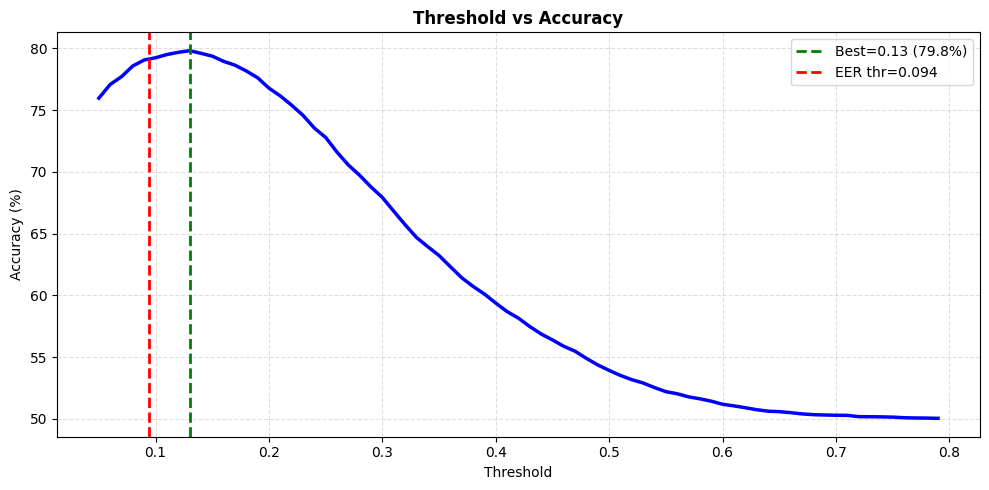

Verifier threshold updated to: 0.1300


In [36]:
y = np.array(results['y_true'])
s = np.array(results['all_scores'])

best_thr, best_acc = 0.0, 0.0
thresholds = np.arange(0.05, 0.80, 0.01)
accs = []
for thr in thresholds:
    preds = (s >= thr).astype(np.int32)
    acc = np.mean(preds == y)
    accs.append(acc)
    if acc > best_acc:
        best_acc = acc; best_thr = thr

print(f'Best threshold: {best_thr:.2f} (accuracy={best_acc*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, [a*100 for a in accs], 'b-', lw=2.5)
ax.axvline(best_thr, color='g', ls='--', lw=2, label=f'Best={best_thr:.2f} ({best_acc*100:.1f}%)')
if results['threshold_eer']:
    ax.axvline(results['threshold_eer'], color='r', ls='--', lw=2,
               label=f"EER thr={results['threshold_eer']:.3f}")
ax.set_xlabel('Threshold'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Threshold vs Accuracy', fontweight='bold')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

verifier.threshold = best_thr
print(f'Verifier threshold updated to: {best_thr:.4f}')

---
## 7. Fine-tune Backbone (Optional)

Fine-tune the ArcFace backbone with contrastive loss on training pairs.
This directly optimizes the embedding for one-shot verification.

After fine-tuning, re-run Sections 4-6 to see improved results.

In [37]:
# Fine-tune the backbone on training data (dataset_final/train)
verifier.fine_tune(
    train_dir='dataset_final/train',
    val_dir='dataset_final/val',
    output_path='using_pretrained_model/finetuned_backbone.h5',
    epochs=15,
    batch_size=32,
    pairs_per_epoch=20000,
    lr=0.0001,
    contrastive_margin=0.5,
    freeze_ratio=0.7,
    val_pairs=5000,
    seed=42,
)
print('Fine-tuning complete. Now re-run Sections 4-6 to evaluate.')

AttributeError: 'FaceVerifier' object has no attribute 'fine_tune'

In [ ]:
# Reload verifier with fine-tuned weights
verifier = FaceVerifier(
    weights_path='using_pretrained_model/finetuned_backbone.h5',
    threshold=verifier.threshold,
)
print('Fine-tuned verifier ready. Re-run evaluate_dataset or identify cells.')